# ZADANIE 1:
Załaduj zdjęcie kota z bazy data.chelsea().

Zamiast drastycznie ściskać zdjęcie, najpierw utnij brzegi (wykonaj center crop) tak by zdjęcie stało się kwadratem, a DOPIERO POTEM przeskaluj je do wymiarów 128x128. Wyświetl na wykresie oryginał oraz wynik prac.

#import zdjęcia wykonasz poprzez uruchomienie
cat_image = data.chelsea()

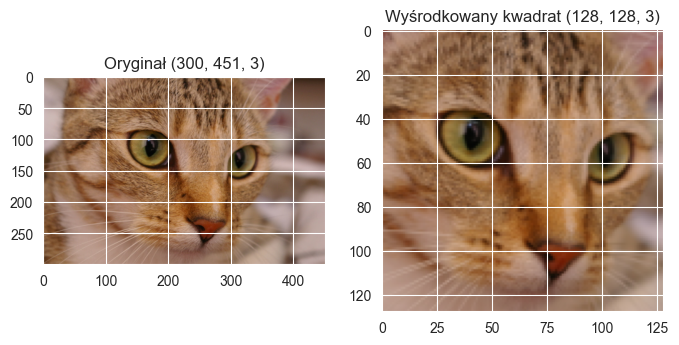

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform, color, util

#wycięcie do kwadatu
cat_image = data.chelsea()
h, w = cat_image.shape[:2]
min_dim = min(h, w)
start_y = (h - min_dim) // 2
start_x = (w - min_dim) // 2

cat_cropped = cat_image[start_y : start_y + min_dim, start_x : start_x + min_dim]

#przeskalowanie
cat_resized = transform.resize(cat_cropped, (128, 128))


fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(cat_image)
ax[0].set_title(f"Oryginał {cat_image.shape}")
ax[1].imshow(cat_resized)
ax[1].set_title(f"Wyśrodkowany kwadrat {cat_resized.shape}")
plt.show()

# ZADANIE 2:
Weź zdjęcie astronauty (image_resized_example wyżej).

Przekonwertuj je do skali szarości używając color.rgb2gray.
Spłaszcz (metoda .flatten() lub .reshape(-1)) tak, by powstał jeden wektor z pikselami.
Wypisz za pomocą print() jego kształt (powinno wynosić 128 * 128 = 16384 cech).

In [12]:
image_resized_example = transform.resize(data.astronaut(), (128, 128))

image_gray = color.rgb2gray(image_resized_example)
image_flat = image_gray.flatten()

print(f"Kształt przed spłaszczeniem: {image_gray.shape}")
print(f"Kształt po spłaszczeniu (128 * 128): {image_flat.shape}")

Kształt przed spłaszczeniem: (128, 128)
Kształt po spłaszczeniu (128 * 128): (16384,)


# ZADANIE 3:
Użyj StandardScaler ze scikit-learn.

Zaaplikuj go do uzyskanego w Zadaniu 2 spłaszczonego, szarego wektora.
#### UWAGA:
StandardScaler przyjmuje dane 2D (wiersze=próbki, kolumny=cechy), więc musisz zmienić kształt wektora na reshape(1, -1) zanim wykonasz .fit_transform().

Wypisz z użyciem metody .mean() i .std() średnią i odchylenie standardowe NOWEGO, przeskalowanego wektora.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
image_flat_2d = image_flat.reshape(1, -1)

#skalowanie
image_scaled = scaler.fit_transform(image_flat_2d)

print(f"Średnia przeskalowanego wektora: {image_scaled.mean():.4f}")
print(f"Odchylenie standardowe: {image_scaled.std():.4f}")

Średnia przeskalowanego wektora: 0.0000
Odchylenie standardowe: 0.0000


# ZADANIE 4:
Posługując się podstawowym, kolorowym obrazem data.astronaut() wykonaj:

Lustrzane odbicie poziome (użyj slice'owania np. img[:, ::-1, :] albo funkcji bibliotecznych z np. np.fliplr).
Dodaj szum za pomocą funkcji util.random_noise() do oryginalnego zdjęcia.
Wyświetl oryginalny obraz oraz oba zmodyfikowane w jednym rzędzie na 3 wykresach.

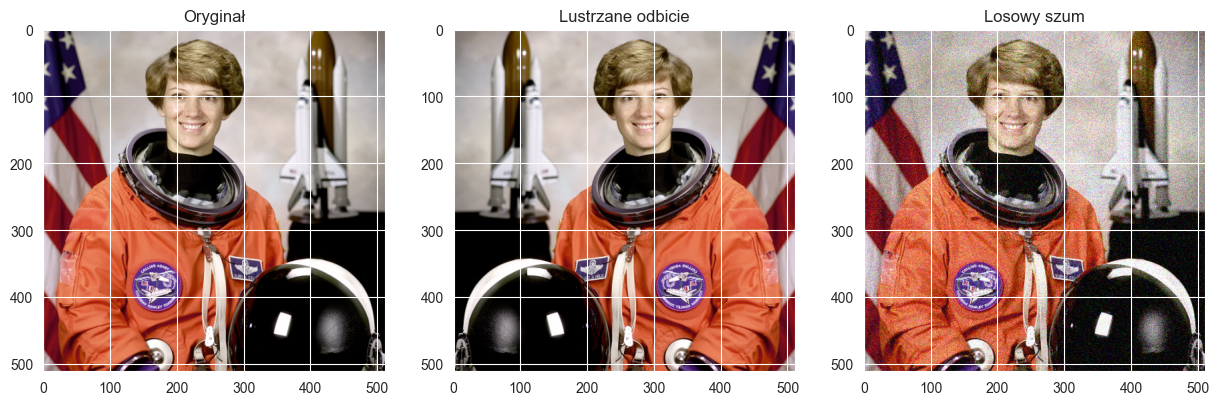

In [14]:
astro_oryginal = data.astronaut()

# odbicie lustrzane
astro_flipped = astro_oryginal[:, ::-1, :]

# szum
astro_noisy = util.random_noise(astro_oryginal)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(astro_oryginal)
ax[0].set_title("Oryginał")

ax[1].imshow(astro_flipped)
ax[1].set_title("Lustrzane odbicie")

ax[2].imshow(astro_noisy)
ax[2].set_title("Losowy szum")

plt.show()

# ZADANIE 5:
Zbuduj model PCA, ale ustaw jego parametr n_components np. na 0.90 (dzięki temu model dobierze tyle komponentów, aby zachować 90% oryginalnej wariancji/informacji).
Przepuść dane X przez ten model używając fit_transform(). Zapisz je do zmiennej np. X_pca.
Sprawdź, ile komponentów ostatecznie zachował algorytm używając parametru instancji: pca.n_components_.
Wykonaj odwrotność kompresji za pomocą inverse_transform na X_pca i nadpisz do zmiennej X_recovered.
Narysuj za pomocą Matplotlib na wykresie oryginalną pierwszą cyfrę X[0].reshape(8, 8) oraz jej wersję odtworzoną z kompresji X_recovered[0].reshape(8, 8).

Ilość początkowych pikseli (wymiarów): 64
Ilość zachowanych komponentów (wymiarów) po kompresji PCA: 21


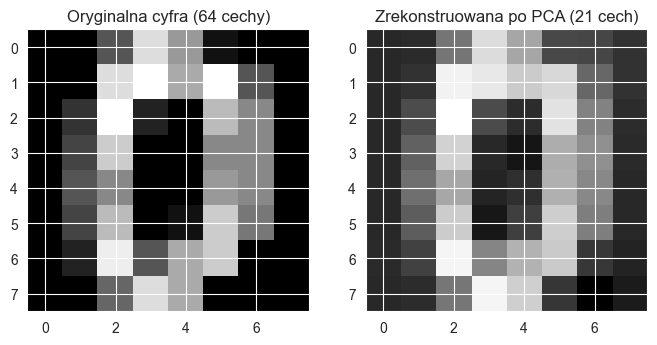

In [16]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits = load_digits()
X = digits.data

# tworzenie modelu PCA wymuszając zachowanie 90% warincji/informacji
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X)

print(f"Ilość początkowych pikseli (wymiarów): {X.shape[1]}")
print(f"Ilość zachowanych komponentów (wymiarów) po kompresji PCA: {pca.n_components_}")

# dekompresja danych
X_recovered = pca.inverse_transform(X_pca)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(X[0].reshape(8, 8), cmap='gray')
ax[0].set_title("Oryginalna cyfra (64 cechy)")

ax[1].imshow(X_recovered[0].reshape(8, 8), cmap='gray')
ax[1].set_title("Zrekonstruowana po PCA (21 cech)")

plt.show()

# ZADANIE 6
Wykorzystując przykłady z poprzednich zadań przygotuj:

Funkcję flip_or_not_to_flip(img, prob=0.5), która z podanym prawdopodobieństwem wykona lustrzane odbicie przekazanego obrazu i go zwróci.
Funkcję gray_or_not_gray(img, prob=0.5), która z podanym prawdopodobieństem przekonwertuje obraz na odcienie szarości.
Funkcję proprocess_images, która przyjmie listę plików\obrazów do przetworzenia, w której:
przekazujemy do funkcji docelowy rozmiar obrazu (do przeskalowania) - sprawdzaj czy przeskalowanie oraz kadrowanie jest konieczne,
następnie wywołuj metody z podpunktów 1 oraz 2,
obrazy zapisujemy do folderu (ścieżka wskazana w wyłowaniu funkcji preprocess_images).
Do załadowania przykładowych obrazów (możesz użyć innych) można wykorzystać poniższy kod (ale uważaj na wywołanie wbudowanej metody eval(), może być to czasami bardzo ryzykowne!

img_list = ['rocket', 'astronaut', 'retina', 'grass', 'camera', 'cat', 'coffee']
for img in img_list:
    plt.imshow(eval(f'data.{img}()'))
    plt.show()

In [17]:
import os
import random

def flip_or_not_to_flip(img, prob=0.5):
    if random.random() < prob:
        if img.ndim == 3:
            return img[:, ::-1, :]
        else:
            return img[:, ::-1]
    return img

def gray_or_not_gray(img, prob=0.5):
    if random.random() < prob and img.ndim == 3:
        return color.rgb2gray(img)
    return img

def preprocess_images(img_list, target_size, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    for img_name in img_list:
        img = eval(f"data.{img_name}()")

        h, w = img.shape[:2]
        if h != target_size[0] or w != target_size[1]:
            min_dim = min(h, w)
            sy = (h - min_dim) // 2
            sx = (w - min_dim) // 2
            img = img[sy : sy+min_dim, sx : sx+min_dim]
            img = transform.resize(img, target_size)

        img = flip_or_not_to_flip(img, prob=0.5)
        img = gray_or_not_gray(img, prob=0.5)

        cmap_val = 'gray' if img.ndim == 2 else None

        file_path = os.path.join(save_dir, f"{img_name}_processed.png")
        plt.imsave(file_path, img, cmap=cmap_val)

    print(f"Pomyślnie przetworzono i zapisano {len(img_list)} obrazów do katalogu: '{save_dir}'")

lista_zdjec = ['rocket', 'astronaut', 'retina', 'grass', 'camera', 'cat', 'coffee']
preprocess_images(img_list=lista_zdjec, target_size=(128, 128), save_dir='./moje_dane_treningowe')

Pomyślnie przetworzono i zapisano 7 obrazów do katalogu: './moje_dane_treningowe'
